# Tutorial 2: Acquiring Tidal Data (``module_tidal``)
This tutorial demonstrates how to retrieve and process tidal resource data using the ``process_tidal_data`` function in ``vital.module_tidal``.

The tutorial covers:

1. Importing required modules.
2. Defining a NOAA station and time range.
3. Processing tidal data.
4. Inspecting processed tidal metadata.
5. Visualizing tidal flow speeds.

A short optional local-file example is included at the end of the tutorial for users who want to work without NOAA access.

## Notes for new users

- Flow speeds are returned in meters per second.
- Time is returned in seconds from the beginning of the requested period.
- NOAA current prediction speeds are converted from cm/s to m/s.
- Flow speeds are converted to nonnegative values using ``abs``.
- A small minimum flow-speed floor is applied internally to avoid numerical issues.
- NOAA API requests can fail because of internet connectivity, NOAA service availability, certificate handling, or station/date limitations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib3

from vital.module_tidal import process_tidal_data

# Suppress warnings caused by NOAA requests using verify=False internally.
# This avoids noisy notebook output.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

## 1. Define input parameters

Set the NOAA station identifier and the start date for tidal data retrieval.

You can find NOAA current station information here:

- NOAA Currents: https://tidesandcurrents.noaa.gov/noaacurrents/
- Alaska stations: https://tidesandcurrents.noaa.gov/noaacurrents/stations.html?g=693

The ``startdate`` should be provided in NOAA-compatible format.

For this example, we use:

- ``station = "COI0303"``
- ``startdate = "2021-09-01"``
- ``range_hrs = 2 * 7 * 24``, corresponding to two weeks.
- ``time_step_s = 3600``, corresponding to one-hour spacing.

The city data file is used to estimate the nearest city and a simplified cable length.

In [2]:
station = "COI0303"
startdate = "2021-09-01"

range_hrs = 2 * 7 * 24
time_step_s = 3600

# The default process_tidal_data path is "../data/AlaskaCityLatLong.txt".
# Here we make it explicit so users know where the city metadata comes from.
city_data_file = "../data/AlaskaCityLatLong.txt"

## 2. Process tidal data from NOAA

The simplest workflow is to call ``process_tidal_data`` with the station, start date, time range, and time step.

In this section, VITAL retrieves tidal data from NOAA. A separate optional local-file example is provided later in the tutorial.

The function returns a ``TidalResults`` dataclass with the following fields:

- ``flow_speeds``: processed flow speeds in m/s
- ``times``: time vector in seconds
- ``mooring_distance``: mooring depth/distance in m
- ``latitude``: station/buoy latitude in radians
- ``longitude``: station/buoy longitude in radians
- ``station_name``: station name
- ``nearest_city``: nearest city estimated from the city data file
- ``cable_length``: estimated electrical cable length in m
- ``source``: data source used, such as ``"NOAA"`` or ``"local_file"``

In [3]:
results = process_tidal_data(
    station=station,
    startdate=startdate,
    range_hrs=range_hrs,
    time_step_s=time_step_s,
    city_data_file=city_data_file,
)

print(f"Data source used: {results.source}")

Data source used: NOAA


## 3. Inspect the processed tidal data

The returned object stores both the time-series resource data and site metadata.

In [4]:
print(f"Data source: {results.source}")
print(f"Station Name: {results.station_name}")
print(f"Nearest City: {results.nearest_city}")
print(f"Mooring Distance (m): {results.mooring_distance}")
print(f"Cable Length (m): {results.cable_length}")
print(f"Buoy Latitude (rad): {results.latitude}")
print(f"Buoy Longitude (rad): {results.longitude}")
print(f"Buoy Latitude (deg): {np.degrees(results.latitude)}")
print(f"Buoy Longitude (deg): {np.degrees(results.longitude)}")

print()
print(f"Number of time samples: {len(results.times)}")
print(f"Number of flow-speed samples: {len(results.flow_speeds)}")
print(f"Minimum flow speed (m/s): {min(results.flow_speeds):.4f}")
print(f"Maximum flow speed (m/s): {max(results.flow_speeds):.4f}")

Data source: NOAA
Station Name: Port Mackenzie, South of
Nearest City: Anchorage
Mooring Distance (m): 31.1
Cable Length (m): 3970.22
Buoy Latitude (rad): 1.0690534367546967
Buoy Longitude (rad): -2.6166093082958874
Buoy Latitude (deg): 61.25225
Buoy Longitude (deg): -149.92067000000003

Number of time samples: 336
Number of flow-speed samples: 336
Minimum flow speed (m/s): 0.0265
Maximum flow speed (m/s): 2.9882


## 4. Plot flow speeds

The time vector is stored in seconds. For plotting, we convert seconds to days.

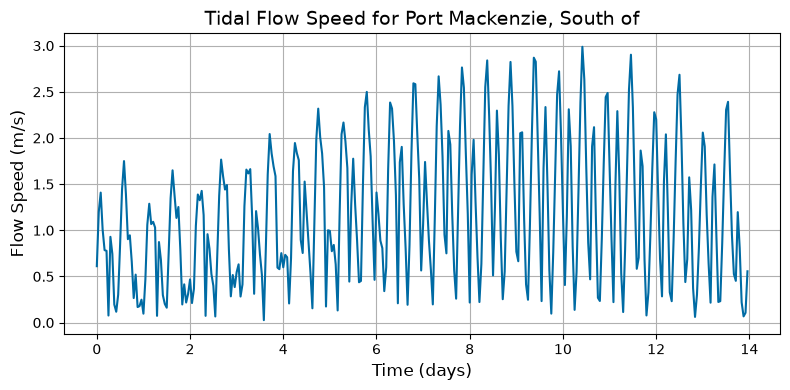

In [5]:
plt.figure(figsize=(8, 4))
plt.plot(results.times / (3600 * 24), results.flow_speeds)
plt.xlabel("Time (days)", fontsize=12)
plt.ylabel("Flow Speed (m/s)", fontsize=12)
plt.title(f"Tidal Flow Speed for {results.station_name}", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Optional: Load tidal data from a local file

NOAA data access may fail because of network restrictions, NOAA API availability, station limitations, or certificate handling.

This optional section shows how to load tidal data directly from a local file. This bypasses NOAA and is useful for reproducible examples or offline use.

The local tidal file must be whitespace-delimited and contain at least two columns:

| Column | Meaning |
|---|---|
| ``t`` | Time in seconds |
| ``U`` | Flow speed in m/s |

Example local file format:


```text
t U
0 0.85
3600 1.10
7200 0.95
10800 0.40
```

When loading a local file directly, the time vector comes from the ``t`` column in the file.
When using a local tidal file, the user must also provide metadata because the station information is no longer coming from NOAA.

- ``station_name``
- ``latitude_deg``
- ``longitude_deg``
- ``mooring_distance_m``

Optional metadata keys are:

- ``nearest_city``
- ``cable_length_m``

If ``city_data_file`` is supplied, the software will attempt to compute the nearest city and cable length from the fallback latitude and longitude.

If this automatic calculation succeeds, it may replace the optional ``nearest_city`` and ``cable_length_m`` values supplied in ``fallback_metadata``.



Data source: local_file
Station Name: COI0303 Local Example
Nearest City: Anchorage
Mooring Distance (m): 50.0
Cable Length (m): 3965.33
Latitude (deg): 61.2522
Longitude (deg): -149.9207
Number of time samples: 336
Minimum flow speed (m/s): 0.0265
Maximum flow speed (m/s): 2.9882


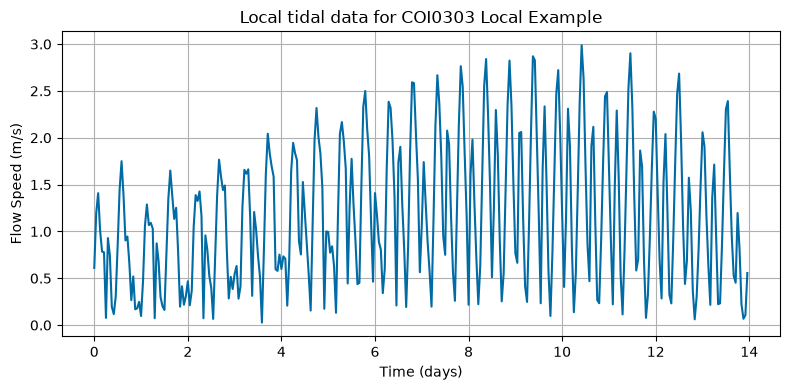

In [6]:
from pathlib import Path
from vital.module_tidal import TidalData, TidalResults

# Example local tidal file.
# Update this path if you want to use a different local dataset.
local_file = "../data/TidalData/COI0303_20210901.txt"

fallback_metadata = {
    "station_name": "COI0303 Local Example",
    "nearest_city": "Port Mackenzie",
    "latitude_deg": 61.2522,
    "longitude_deg": -149.9207,
    "mooring_distance_m": 50.0,
    "cable_length_m": 1000.0,
}

if Path(local_file).exists():
    local_tidal_loader = TidalData(
        station=station,
        startdate=startdate,
        range_hrs=range_hrs,
        time_step_s=time_step_s,
    )

    local_results_tuple = local_tidal_loader.load_local_tidal_data(
        local_file=local_file,
        fallback_metadata=fallback_metadata,
        city_data_file=city_data_file,
    )

    local_results = TidalResults(*local_results_tuple)

    print(f"Data source: {local_results.source}")
    print(f"Station Name: {local_results.station_name}")
    print(f"Nearest City: {local_results.nearest_city}")
    print(f"Mooring Distance (m): {local_results.mooring_distance}")
    print(f"Cable Length (m): {local_results.cable_length}")
    print(f"Latitude (deg): {np.degrees(local_results.latitude)}")
    print(f"Longitude (deg): {np.degrees(local_results.longitude)}")
    print(f"Number of time samples: {len(local_results.times)}")
    print(f"Minimum flow speed (m/s): {min(local_results.flow_speeds):.4f}")
    print(f"Maximum flow speed (m/s): {max(local_results.flow_speeds):.4f}")

    plt.figure(figsize=(8, 4))
    plt.plot(local_results.times / (3600 * 24), local_results.flow_speeds)
    plt.xlabel("Time (days)")
    plt.ylabel("Flow Speed (m/s)")
    plt.title(f"Local tidal data for {local_results.station_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

else:
    print(
        "No local fallback file found. "
        "To test local mode, create a whitespace-delimited file with columns 't' and 'U'."
    )